In [47]:
#import necessary libraries
import pandas as pd
import numpy as np

In [ ]:
''' ensure that the csv files is in the current working directory
 this commented code was necesary for my Colab Enviroment but you
 can also change the cell below this one if needed '''

# %cd drive/MyDrive

In [49]:
# save our tabular data to a pandas dataframe
df = pd.read_csv('crocodile_dataset.csv')

In [50]:
# lets observe our columns for EDA
df.columns

Index(['Observation ID', 'Common Name', 'Scientific Name', 'Family', 'Genus',
       'Observed Length (m)', 'Observed Weight (kg)', 'Age Class', 'Sex',
       'Date of Observation', 'Country/Region', 'Habitat Type',
       'Conservation Status', 'Observer Name', 'Notes'],
      dtype='object')

In [51]:
# remove unneccesary columns or columns that will not be known upon immediate inspection
df = df.drop(columns=['Observation ID','Scientific Name',
                      'Family','Genus','Observer Name',
                      'Notes','Date of Observation',
                      'Conservation Status'])


In [52]:
# lets check out datatypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Common Name           1000 non-null   object 
 1   Observed Length (m)   1000 non-null   float64
 2   Observed Weight (kg)  1000 non-null   float64
 3   Age Class             1000 non-null   object 
 4   Sex                   1000 non-null   object 
 5   Country/Region        1000 non-null   object 
 6   Habitat Type          1000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [53]:
# get_dummies allows us to easily one-hot categorical variables
df = pd.get_dummies(df, columns=['Sex', 'Age Class', 'Country/Region', 'Habitat Type'])
df.head()

,Common Name,Observed Length (m),Observed Weight (kg),Sex_Female,Sex_Male,Sex_Unknown,Age Class_Adult,Age Class_Hatchling,Age Class_Juvenile,Age Class_Subadult,...,Habitat Type_Oxbow Lakes,Habitat Type_Ponds,Habitat Type_Reservoirs,Habitat Type_Rivers,Habitat Type_Shaded Forest Rivers,Habitat Type_Slow Rivers,Habitat Type_Slow Streams,Habitat Type_Small Streams,Habitat Type_Swamps,Habitat Type_Tidal Rivers
0,Morelet's Crocodile,1.90,62.0,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,American Crocodile,4.09,334.5,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Orinoco Crocodile,1.08,118.2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,Morelet's Crocodile,2.42,90.4,False,True,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,Mugger Crocodile (Marsh Crocodile),3.75,269.4,False,False,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [54]:
# Create a matrix with features not containing labels
# Then convert to numpy array with numerical data types
X = df.drop(columns=['Common Name'])
X = np.asarray(X, dtype=np.float64)

# Create a matrix of labels
Y = df['Common Name']
Y = np.asarray(Y)

,Common Name,Observed Length (m),Observed Weight (kg),Sex_Female,Sex_Male,Sex_Unknown,Age Class_Adult,Age Class_Hatchling,Age Class_Juvenile,Age Class_Subadult,...,Habitat Type_Oxbow Lakes,Habitat Type_Ponds,Habitat Type_Reservoirs,Habitat Type_Rivers,Habitat Type_Shaded Forest Rivers,Habitat Type_Slow Rivers,Habitat Type_Slow Streams,Habitat Type_Small Streams,Habitat Type_Swamps,Habitat Type_Tidal Rivers
0,Morelet's Crocodile,1.90,62.0,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,American Crocodile,4.09,334.5,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Orinoco Crocodile,1.08,118.2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,Morelet's Crocodile,2.42,90.4,False,True,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,Mugger Crocodile (Marsh Crocodile),3.75,269.4,False,False,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [55]:
# Splitting data for training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

# verify shapes
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((800, 85), (800,), (200, 85), (200,))

In [56]:
# lets try 3 different decision tree algorithms and inference their
# predictability using cross validation (this may take a minute)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(DecisionTreeClassifier(), x_train, y_train, cv=3)
rf_cv_scores = cross_val_score(RandomForestClassifier(), x_train, y_train, cv=3)
gb_cv_scores = cross_val_score(GradientBoostingClassifier(), x_train, y_train, cv=3)

print(dt_cv_scores)
print(rf_cv_scores)
print(gb_cv_scores)

[0.90262172 0.87640449 0.92481203]
[0.9588015  0.94382022 0.95112782]
[0.98127341 0.97752809 0.96992481]


In [57]:
# Gradient Boosting appears to yield the highest cross validation scores
# But for fun, lets ensure Gradient Boosting is the best approach based predicting the test data
dt = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
rf = RandomForestClassifier(random_state=42).fit(x_train, y_train)
gbc = GradientBoostingClassifier(random_state=42).fit(x_train, y_train)

from sklearn.metrics import accuracy_score
dt_pred = dt.predict(x_test)
dt_score = accuracy_score(y_test, dt_pred)

rf_pred = rf.predict(x_test)
rf_score = accuracy_score(y_test, rf_pred)

gbc_pred = gbc.predict(x_test)
gbc_score = accuracy_score(y_test, gbc_pred)

print('Accuracy On Test Data')
print('-'*40)
print(f'Decision Tree Accuracy: {dt_score}')
print(f'Random Forest Accuracy: {rf_score}')
print(f'Gradient Boosted Accuracy: {gbc_score}')

Accuracy On Test Data
----------------------------------------
Decision Tree Accuracy: 0.93
Random Forest Accuracy: 0.965
Gradient Boosted Accuracy: 0.99


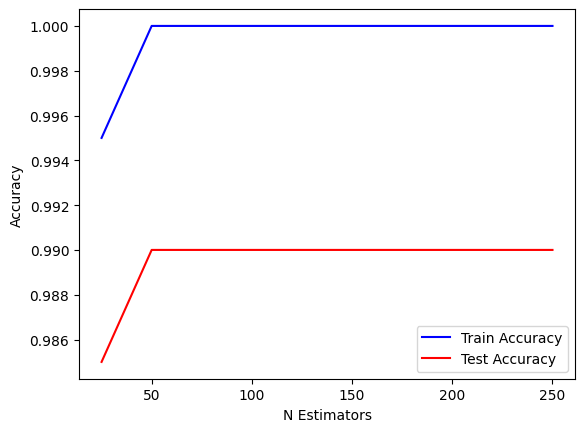

In [23]:
# looks like we were right, so lets tune some hyper-parameters
# lets see how our model performs with a different number of estimators
# (this may take a while)
import matplotlib.pyplot as plt

train_acc = []
test_acc = []
estimators = list(range(25, 275, 25))
for i in estimators:
  model = GradientBoostingClassifier(n_estimators=i, random_state=42)
  model.fit(x_train, y_train)
  y_pred_train = model.predict(x_train)
  y_pred_test = model.predict(x_test)
  train_acc.append(accuracy_score(y_train, y_pred_train))
  test_acc.append(accuracy_score(y_test, y_pred_test))

plt.clf()
plt.plot(estimators, train_acc, c='b', label='Train Accuracy')
plt.plot(estimators, test_acc, c='r', label='Test Accuracy')
plt.xlabel('N Estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

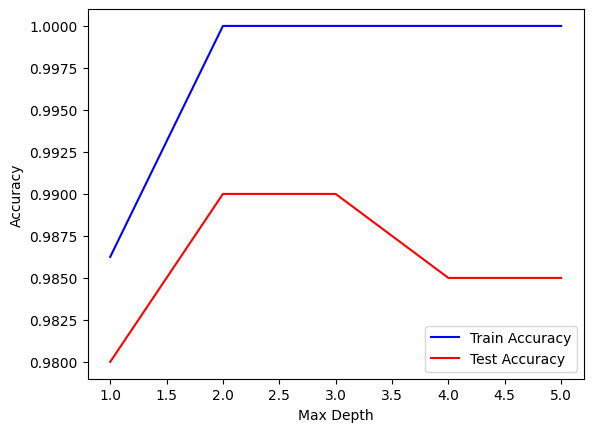

In [24]:
# now lets see how our model performs with different max_depths per weak learner
# (this may take a while)
train_acc = []
test_acc = []
depths = list(range(1, 6))
for i in depths:
  model = GradientBoostingClassifier(max_depth=i, random_state=42)
  model.fit(x_train, y_train)
  y_pred_train = model.predict(x_train)
  y_pred_test = model.predict(x_test)
  train_acc.append(accuracy_score(y_train, y_pred_train))
  test_acc.append(accuracy_score(y_test, y_pred_test))

plt.clf()
plt.plot(depths, train_acc, c='b', label='Train Accuracy')
plt.plot(depths, test_acc, c='r', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


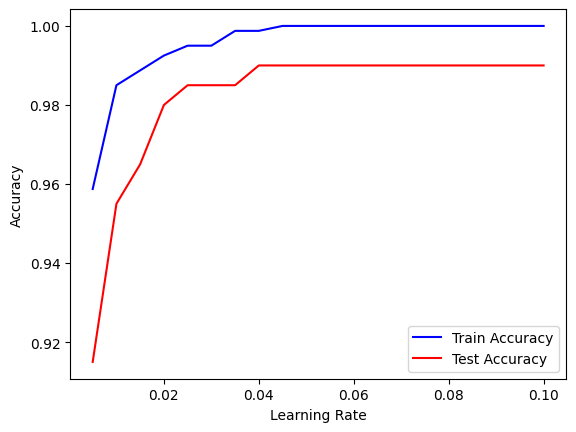

In [62]:
# our model looks almost perfect
# as a last resort to improve, lets plot different values of the hyper-parameter learning_rate
# (again this will take a while)
train_acc = []
test_acc = []
learning_rates = list(np.asarray(range(1, 21)) * .005)
for lr in learning_rates:
  model = GradientBoostingClassifier(learning_rate=lr, random_state=42)
  model.fit(x_train, y_train)
  y_pred_train = model.predict(x_train)
  y_pred_test = model.predict(x_test)
  train_acc.append(accuracy_score(y_train, y_pred_train))
  test_acc.append(accuracy_score(y_test, y_pred_test))

plt.clf()
plt.plot(learning_rates, train_acc, c='b', label='Train Accuracy')
plt.plot(learning_rates, test_acc, c='r', label='Test Accuracy')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [67]:
# From the plots, we see our model performs well but maximizes
# its performance at a max_depth of 3, 50 n_learners, and 0.1 learning_rate

# We can observe some of the benefits of our tuned hyperparameters by
# observing the time it takes to train and predict with a model with default hyper-parameters
# VS a model with our discovered optimal hyper parameters
import time

start = time.perf_counter()
model = GradientBoostingClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
time_taken = time.perf_counter() - start
print(f'Model achieved accuracy of {acc * 100}%')
print(f'in {time_taken} seconds')

start = time.perf_counter()
model = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
time_taken = time.perf_counter() - start
print(f'Adjusted model achieved accuracy of {acc * 100}%')
print(f'in {time_taken} seconds')

Model achieved accuracy of 99.0%
in 7.191245152000192 seconds
Adjusted model achieved accuracy of 99.0%
in 3.422235283000191 seconds


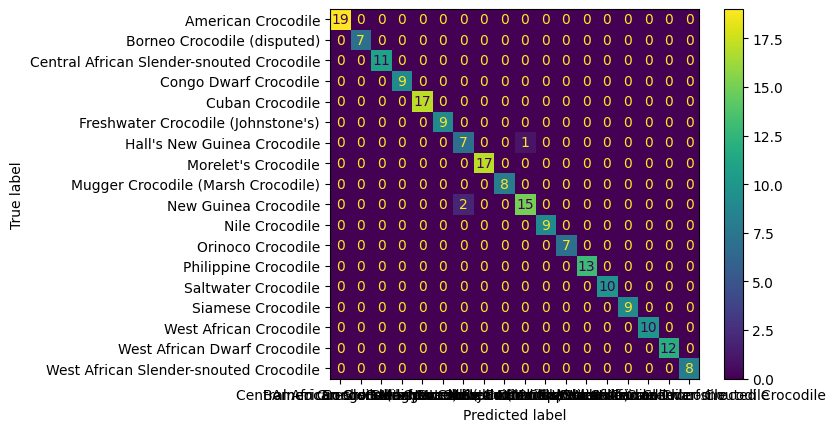

In [45]:
# finally we will plot a confusion matrix to observe what data our model fails to predict
# we can see that our model is almost perfect except that is may confuse a New-Guinea Crocodile
# with the similarly named Hall's New-Guinea Crocodile
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_model = GradientBoostingClassifier(n_estimators=50, max_depth=3)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

labels = best_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()